<a href="https://colab.research.google.com/github/pranacollab/prana-sentinel/blob/main/notebooks/prana_sentinel_poc_02_satellite_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

We're going to pull NASA MODIS satellite data for the same Rio de Janeiro time period, specifically:

Land Surface Temperature (LST) — heat is a key driver of mosquito breeding Normalized Difference Vegetation Index (NDVI) — vegetation density correlates with mosquito habitat

We'll use Google Earth Engine (GEE) for this, which is free and integrates well with Colab.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!pip install earthengine-api geemap

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import ee
import geemap
import pandas as pd

In [ ]:
ee.Authenticate()

True

In [ ]:
ee.Initialize(project='ee-denguebrasil')

In [ ]:
# Cell 1
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Cell 2
!pip install earthengine-api geemap

In [ ]:
# Cell 3
import ee
import geemap
import pandas as pd

In [ ]:
# Cell 4
ee.Authenticate()

True

In [ ]:
# Cell 5
ee.Initialize(project='ee-denguebrasil')

In [ ]:
print(ee.String('Earth Engine connected').getInfo())

Earth Engine connected


In [ ]:
# Define Rio de Janeiro area
rio = ee.Geometry.Point([-43.1729, -22.9068]).buffer(50000)  # 50km radius

# Pull MODIS Land Surface Temperature
lst = ee.ImageCollection('MODIS/061/MOD11A2') \
    .filterDate('2022-01-01', '2023-12-31') \
    .filterBounds(rio) \
    .select('LST_Day_1km')

# Extract mean LST per image (each image = 8 day composite)
def extract_lst(image):
    mean = image.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=rio,
        scale=1000
    )
    return image.set('date', image.date().format('YYYY-MM-dd')) \
                .set('LST_mean', mean.get('LST_Day_1km'))

lst_mapped = lst.map(extract_lst)

# Convert to dataframe
lst_list = lst_mapped.reduceColumns(
    ee.Reducer.toList(2), ['date', 'LST_mean']
).get('list')

lst_data = lst_list.getInfo()
df_lst = pd.DataFrame(lst_data, columns=['date', 'LST_kelvin'])

# MODIS LST is in Kelvin * 0.02 — convert to Celsius
df_lst['LST_celsius'] = (df_lst['LST_kelvin'] * 0.02) - 273.15
df_lst['date'] = pd.to_datetime(df_lst['date'])
df_lst = df_lst.sort_values('date')

print(df_lst.head(10))

        date    LST_kelvin  LST_celsius
0 2022-01-09  15102.731503    28.904630
1 2022-01-17  15260.903887    32.068078
2 2022-01-25  15298.176747    32.813535
3 2022-02-02  15296.767328    32.785347
4 2022-02-10  15156.994443    29.989889
5 2022-02-18  15074.432277    28.338646
6 2022-02-26  15269.187937    32.233759
7 2022-03-06  15287.997763    32.609955
8 2022-03-14  15244.469790    31.739396
9 2022-03-22  15176.929096    30.388582


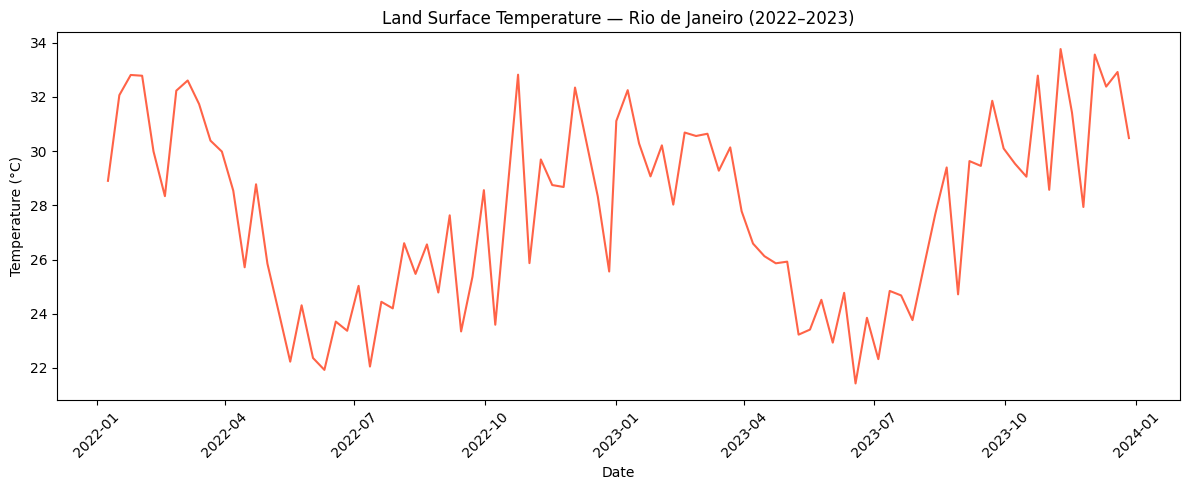

Saved successfully!


In [ ]:
import matplotlib.pyplot as plt

# Plot LST over time
plt.figure(figsize=(12, 5))
plt.plot(df_lst['date'], df_lst['LST_celsius'], color='tomato')
plt.title('Land Surface Temperature — Rio de Janeiro (2022–2023)')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Save to Drive
df_lst.to_csv('/content/drive/MyDrive/prana_sentinel_poc_02_lst_rio.csv', index=False)
print("Saved successfully!")

In [ ]:
# Pull MODIS NDVI data
ndvi = ee.ImageCollection('MODIS/061/MOD13A2') \
    .filterDate('2022-01-01', '2023-12-31') \
    .filterBounds(rio) \
    .select('NDVI')

def extract_ndvi(image):
    mean = image.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=rio,
        scale=1000
    )
    return image.set('date', image.date().format('YYYY-MM-dd')) \
                .set('NDVI_mean', mean.get('NDVI'))

ndvi_mapped = ndvi.map(extract_ndvi)

ndvi_list = ndvi_mapped.reduceColumns(
    ee.Reducer.toList(2), ['date', 'NDVI_mean']
).get('list')

ndvi_data = ndvi_list.getInfo()
df_ndvi = pd.DataFrame(ndvi_data, columns=['date', 'NDVI_raw'])

# MODIS NDVI scale factor is 0.0001
df_ndvi['NDVI'] = df_ndvi['NDVI_raw'] * 0.0001
df_ndvi['date'] = pd.to_datetime(df_ndvi['date'])
df_ndvi = df_ndvi.sort_values('date')

print(df_ndvi.head(10))

        date     NDVI_raw      NDVI
0 2022-01-01  3399.626075  0.339963
1 2022-01-17  6633.961319  0.663396
2 2022-02-02  6801.943200  0.680194
3 2022-02-18  6769.778917  0.676978
4 2022-03-06  6645.005461  0.664501
5 2022-03-22  6595.469714  0.659547
6 2022-04-07  6811.283550  0.681128
7 2022-04-23  6746.784456  0.674678
8 2022-05-09  6812.751175  0.681275
9 2022-05-25  6683.688100  0.668369


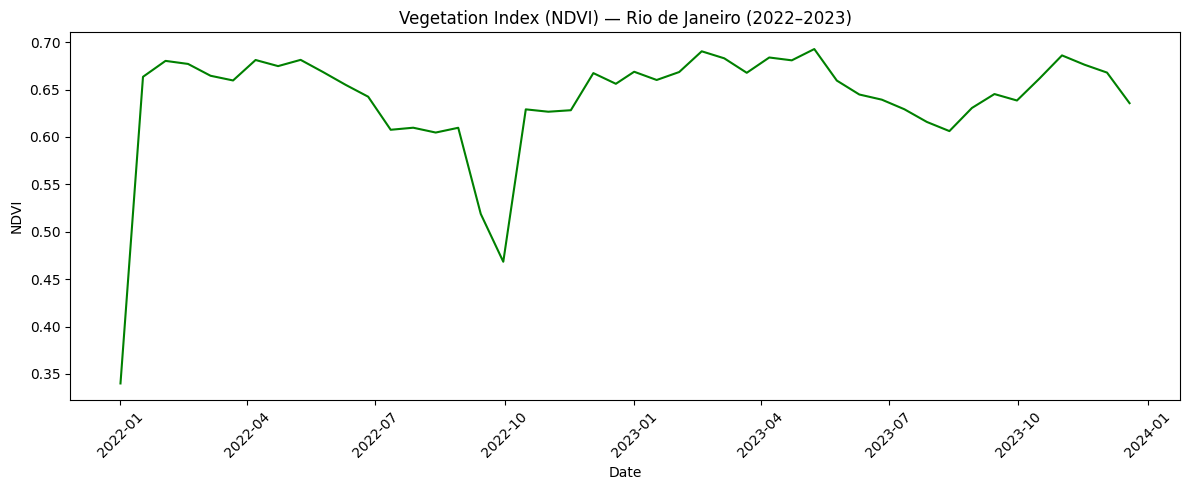

Saved successfully!


In [ ]:
# Plot NDVI over time
plt.figure(figsize=(12, 5))
plt.plot(df_ndvi['date'], df_ndvi['NDVI'], color='green')
plt.title('Vegetation Index (NDVI) — Rio de Janeiro (2022–2023)')
plt.xlabel('Date')
plt.ylabel('NDVI')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Save to Drive
df_ndvi.to_csv('/content/drive/MyDrive/prana_sentinel_poc_02_ndvi_rio.csv', index=False)
print("Saved successfully!")

## Notebook 02 — Summary

In this notebook we connected Google Colab to NASA's satellite data
infrastructure via Google Earth Engine (GEE), using the project
ee-denguebrasil under Ananta Holding Group's Prana Sentinel initiative.

We pulled two key environmental datasets for Rio de Janeiro covering
2022–2023:

1. Land Surface Temperature (LST) — sourced from the MODIS MOD11A2
   collection, converted from raw Kelvin values to Celsius. Temperature
   ranged from approximately 21°C in the winter months to 33°C in the
   Brazilian summer, closely mirroring the seasonal dengue outbreak
   patterns observed in Notebook 01.

2. Vegetation Index (NDVI) — sourced from the MODIS MOD13A2 collection,
   scaled using the standard 0.0001 factor. NDVI remained relatively
   stable between 0.60–0.68, consistent with Rio's dense tropical
   environment.

Both datasets were saved to Google Drive for use in Notebook 03, where
they will be merged with the dengue case data and used to train a
predictive model — the core proof of concept for Prana Sentinel as a
Space-Enabled Health Intelligence System (SEHIS).